## Import Library and Load Data

Pandas dan NumPy digunakan untuk pengolahan data, Matplotlib untuk visualisasi, Scikit-learn untuk preprocessing dan evaluasi, sedangkan TensorFlow/Keras digunakan untuk membangun serta melatih model LSTM. Selain itu, pengaturan seed, callback, dan regularisasi diterapkan untuk memastikan proses pelatihan berjalan stabil, hasil eksperimen dapat direproduksi, serta model memiliki kemampuan generalisasi yang lebih baik.

In [53]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
import random, os

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (mean_squared_error, mean_absolute_error)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (LSTM, Dense, Dropout)
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau)
from tensorflow.keras.regularizers import l2

plt.style.use("seaborn-v0_8")

In [54]:
datasets = {
    "AMZN": pd.read_csv("AMZN.csv", parse_dates=["Date"]),
    "CSCO": pd.read_csv("CSCO.csv", parse_dates=["Date"])
}

## Nomor 1A. EDA dan Preprocessing

### EDA

Tahap pertama dilakukan eksplorasi data (Exploratory Data Analysis/EDA) untuk memahami karakteristik data saham sebelum dilakukan pemodelan. Berdasarkan visualisasi time series, harga penutupan saham menunjukkan pola yang berubah seiring waktu dengan kecenderungan tren naik maupun turun pada periode tertentu. Hal ini menunjukkan bahwa data memiliki sifat non-stasioner, yaitu nilai rata-rata dan varians berubah sepanjang waktu. Karakteristik seperti ini umum ditemukan pada data harga saham sehingga model yang mampu mempelajari hubungan temporal, seperti LSTM, lebih sesuai digunakan dibandingkan model regresi biasa.

In [55]:
for name, df in datasets.items():
    print(f"\n=== {name} Dataset ===")

    display(df.head())


=== AMZN Dataset ===


,Date,Open,High,Low,Close,Adj Close,Volume
0,1997-05-15,2.437500,2.500000,1.927083,1.958333,1.958333,72156000
1,1997-05-16,1.968750,1.979167,1.708333,1.729167,1.729167,14700000
2,1997-05-19,1.760417,1.770833,1.625000,1.708333,1.708333,6106800
3,1997-05-20,1.729167,1.750000,1.635417,1.635417,1.635417,5467200
4,1997-05-21,1.635417,1.645833,1.375000,1.427083,1.427083,18853200



=== CSCO Dataset ===


,Date,Open,High,Low,Close,Adj Close,Volume
0,1990-02-16,0.0,0.079861,0.073785,0.077257,0.059806,940636800
1,1990-02-20,0.0,0.079861,0.074653,0.079861,0.061822,151862400
2,1990-02-21,0.0,0.078993,0.075521,0.078125,0.060478,70531200
3,1990-02-22,0.0,0.081597,0.078993,0.078993,0.061150,45216000
4,1990-02-23,0.0,0.079861,0.078125,0.078559,0.060814,44697600


In [56]:
for name, df in datasets.items():
    print(f"\n=== {name} ===")

    print(df.info())


=== AMZN ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5758 entries, 0 to 5757
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       5758 non-null   datetime64[ns]
 1   Open       5758 non-null   float64       
 2   High       5758 non-null   float64       
 3   Low        5758 non-null   float64       
 4   Close      5758 non-null   float64       
 5   Adj Close  5758 non-null   float64       
 6   Volume     5758 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 315.0 KB
None

=== CSCO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7589 entries, 0 to 7588
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       7589 non-null   datetime64[ns]
 1   Open       7589 non-null   float64       
 2   High       7589 non-null   float64       
 3   Low        7589 non-n

In [57]:
for name, df in datasets.items():
    print(f"\n=== {name} ===")

    display(df.describe())


=== AMZN ===


,Date,Open,High,Low,Close,Adj Close,Volume
count,5758,5758.000000,5758.000000,5758.000000,5758.000000,5758.000000,5.758000e+03
mean,2008-10-22 21:30:41.889544960,340.458153,344.156408,336.344390,340.417580,340.417580,7.556094e+06
min,1997-05-15 00:00:00,1.406250,1.447917,1.312500,1.395833,1.395833,4.872000e+05
25%,2003-02-05 06:00:00,37.460001,38.334999,36.812499,37.562500,37.562500,3.685525e+06
50%,2008-10-22 12:00:00,81.965000,83.520000,79.875000,81.599998,81.599998,5.692450e+06
75%,2014-07-14 18:00:00,335.267494,337.537491,331.727501,334.290001,334.290001,8.594350e+06
max,2020-04-01 00:00:00,2173.070068,2185.949951,2161.120117,2170.219971,2170.219971,1.043292e+08
std,NaN,523.365374,528.138556,517.726971,523.140207,523.140207,7.325904e+06



=== CSCO ===


,Date,Open,High,Low,Close,Adj Close,Volume
count,7589,7589.000000,7589.000000,7589.000000,7589.000000,7589.000000,7.589000e+03
mean,2005-03-05 13:52:02.782975360,20.404527,20.682047,20.116294,20.399541,16.945200,5.680188e+07
min,1990-02-16 00:00:00,0.000000,0.072917,0.068576,0.071181,0.055102,8.064000e+05
25%,1997-08-19 00:00:00,8.444445,8.583333,8.326389,8.479167,6.563846,3.245060e+07
50%,2005-03-07 00:00:00,19.700001,19.937500,19.440001,19.680000,15.311988,4.898850e+07
75%,2012-09-14 00:00:00,27.129999,27.410000,26.830000,27.120001,21.845076,6.822650e+07
max,2020-04-01 00:00:00,81.437500,82.000000,79.062500,80.062500,61.977535,9.406368e+08
std,NaN,14.915392,15.133191,14.676149,14.906589,13.253297,4.168727e+07


#### Check Missing Value

In [58]:
for name, df in datasets.items():
    print(f"\n=== {name} ===")

    print(df.isnull().sum())


=== AMZN ===
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

=== CSCO ===
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


#### Feature Selection

In [59]:
for name in datasets:
    datasets[name] = datasets[name][["Date","Close"]]

Model yang dibangun merupakan prediksi harga penutupan (Close) menggunakan pendekatan time series univariat, sehingga hanya membutuhkan satu variabel utama, yaitu harga penutupan. Kolom Date tetap dipertahankan untuk menjaga urutan waktu, melakukan pembagian data berdasarkan periode, serta mempermudah visualisasi hasil prediksi.

In [60]:
for name in datasets:
    datasets[name] = datasets[name].sort_values("Date")
    datasets[name].reset_index(drop=True, inplace=True)

Data yang digunakan merupakan data time series, sehingga urutan waktu sangat penting. Model LSTM mempelajari hubungan antar data berdasarkan urutan kronologis. Apabila data tidak tersusun berdasarkan tanggal, maka model akan menerima urutan yang salah sehingga pola temporal tidak dapat dipelajari dengan benar dan hasil prediksi menjadi kurang akurat.

In [61]:
for name, df in datasets.items():
    print(f"\n=== {name} ===")
    print("Start Date:", df["Date"].min())
    print("Finish Date:", df["Date"].max())
    print("Number of Data:", len(df))


=== AMZN ===
Start Date: 1997-05-15 00:00:00
Finish Date: 2020-04-01 00:00:00
Number of Data: 5758

=== CSCO ===
Start Date: 1990-02-16 00:00:00
Finish Date: 2020-04-01 00:00:00
Number of Data: 7589


Informasi ini digunakan sebagai tahap awal eksplorasi data (Exploratory Data Analysis/EDA) untuk memastikan bahwa dataset telah dimuat dengan benar dan memiliki rentang waktu yang sesuai. Selain itu, informasi tanggal awal dan tanggal akhir membantu dalam proses pembagian data menjadi training set dan test set, di mana data uji diambil dari periode satu tahun terakhir sesuai ketentuan soal.

Jumlah data juga memberikan gambaran mengenai banyaknya observasi yang tersedia untuk proses pelatihan model. Semakin banyak data historis yang digunakan, umumnya semakin baik kemampuan model dalam mempelajari pola perubahan harga saham.

#### Plot

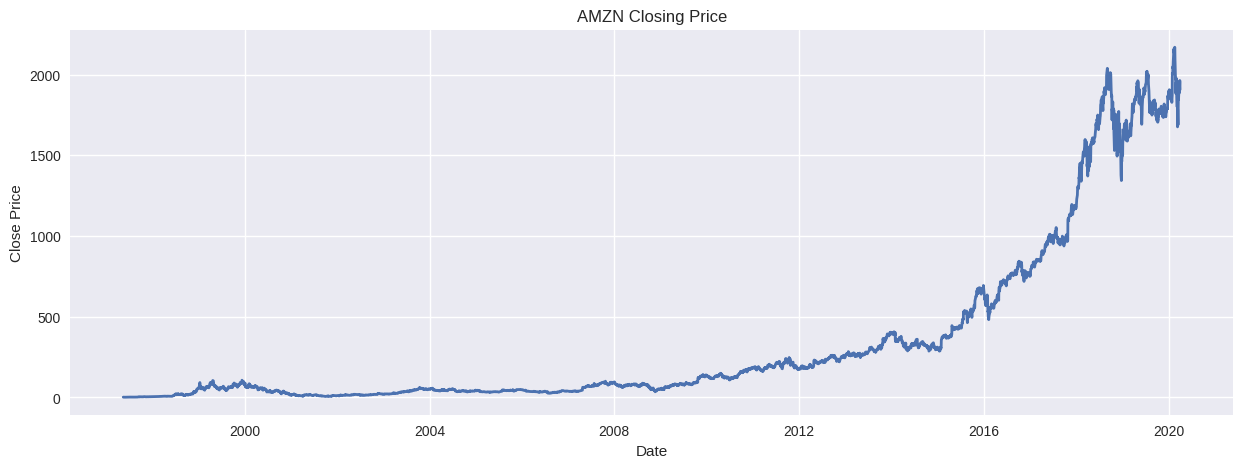

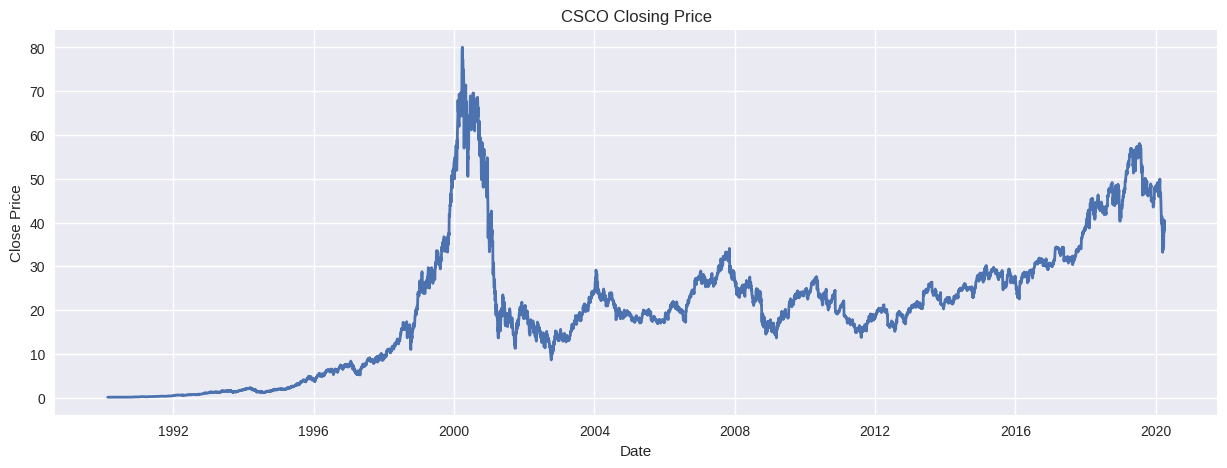

In [62]:
for name, df in datasets.items():
    plt.figure(figsize=(15,5))
    plt.plot(df["Date"], df["Close"], linewidth=2)
    plt.title(f"{name} Closing Price")
    plt.xlabel("Date")
    plt.ylabel("Close Price")
    plt.grid(True)
    plt.show()

Visualisasi time series menunjukkan bahwa kedua dataset memiliki pola pergerakan harga yang berubah seiring waktu. Saham AMZN mengalami tren kenaikan yang sangat signifikan, terutama sejak tahun 2015, meskipun disertai fluktuasi yang cukup tinggi pada beberapa periode. Sementara itu, saham CSCO mengalami lonjakan harga pada sekitar tahun 2000, kemudian mengalami penurunan dan bergerak lebih stabil pada periode berikutnya. Pola ini menunjukkan bahwa kedua dataset memiliki karakteristik data time series dan bersifat non-stasioner sehingga sesuai untuk dimodelkan menggunakan LSTM.

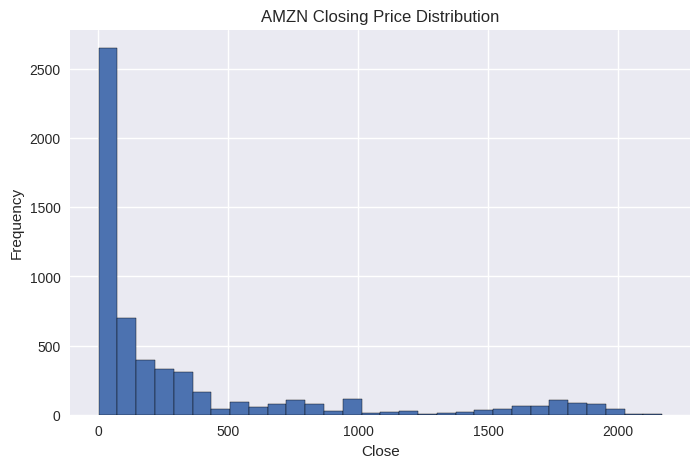

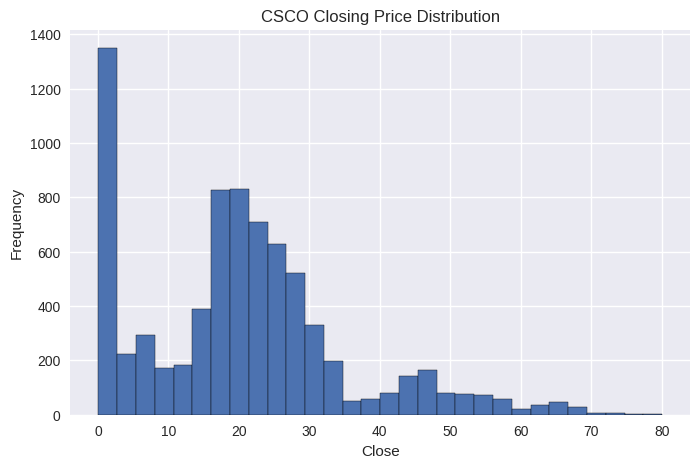

In [63]:
for name, df in datasets.items():
    plt.figure(figsize=(8,5))
    plt.hist(df["Close"], bins=30, edgecolor="black")
    plt.title(f"{name} Closing Price Distribution")
    plt.xlabel("Close")
    plt.ylabel("Frequency")
    plt.show()

Histogram menunjukkan bahwa distribusi harga penutupan pada kedua saham tidak mengikuti distribusi normal dan cenderung right-skewed. Sebagian besar data berada pada harga yang relatif rendah, sedangkan hanya sedikit observasi yang memiliki harga sangat tinggi. Kondisi ini menunjukkan adanya perbedaan rentang nilai yang cukup besar sehingga diperlukan proses normalisasi sebelum dilakukan pemodelan.

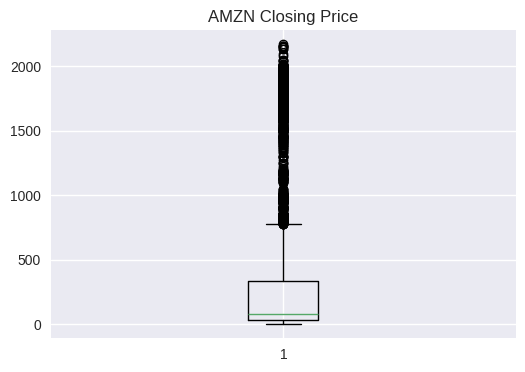

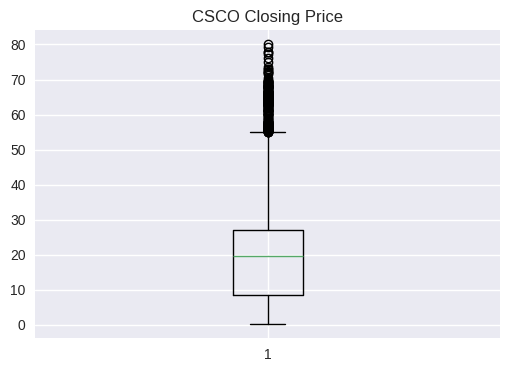

In [64]:
for name, df in datasets.items():
    plt.figure(figsize=(6,4))
    plt.boxplot(df["Close"])
    plt.title(f"{name} Closing Price")
    plt.show()

Berdasarkan boxplot, kedua dataset memiliki sejumlah outlier, terutama pada saham AMZN. Namun, outlier tersebut merupakan akibat dari perubahan harga saham yang nyata di pasar, bukan kesalahan pencatatan data. Oleh karena itu, seluruh data tetap dipertahankan agar model dapat mempelajari kondisi pasar yang sebenarnya.

In [65]:
for name, df in datasets.items():
    print(f"\n=== {name} ===")
    print("Minimum :", df["Close"].min())
    print("Maximum :", df["Close"].max())
    print("Average :", df["Close"].mean())


=== AMZN ===
Minimum : 1.3958333730697632
Maximum : 2170.219970703125
Average : 340.4175803410837

=== CSCO ===
Minimum : 0.0711805522441864
Maximum : 80.0625
Average : 20.39954128281894


Statistik deskriptif menunjukkan bahwa harga saham AMZN memiliki rentang nilai yang jauh lebih besar dibandingkan CSCO, dengan rata-rata masing-masing sebesar 340,42 USD dan 20,40 USD. Perbedaan skala ini menjadi alasan penggunaan MinMaxScaler agar seluruh data berada pada rentang yang sama sehingga proses pelatihan model LSTM menjadi lebih stabil.

### Data Preprocessing

Dataset dipisahkan menjadi data training dan data testing berdasarkan urutan waktu, di mana satu tahun terakhir digunakan sebagai data testing sesuai ketentuan soal. Pembagian dilakukan secara kronologis, bukan secara acak, untuk menghindari data leakage dan memastikan model hanya mempelajari data historis. Dengan demikian, proses evaluasi dapat memberikan gambaran yang lebih realistis terhadap kemampuan model dalam memprediksi harga saham pada periode yang belum pernah dilihat sebelumnya.

In [66]:
processed_data = {}

for name, df in datasets.items():

    cutoff = df["Date"].max() - pd.DateOffset(years=1)

    train_df = df[df["Date"] <= cutoff].copy()
    test_df  = df[df["Date"] >  cutoff].copy()

    processed_data[name] = {
        "train_df" : train_df,
        "test_df"  : test_df
    }

    print(f"{name} --> Train: {len(train_df)} baris | Test: {len(test_df)} baris")

AMZN --> Train: 5505 baris | Test: 253 baris
CSCO --> Train: 7336 baris | Test: 253 baris


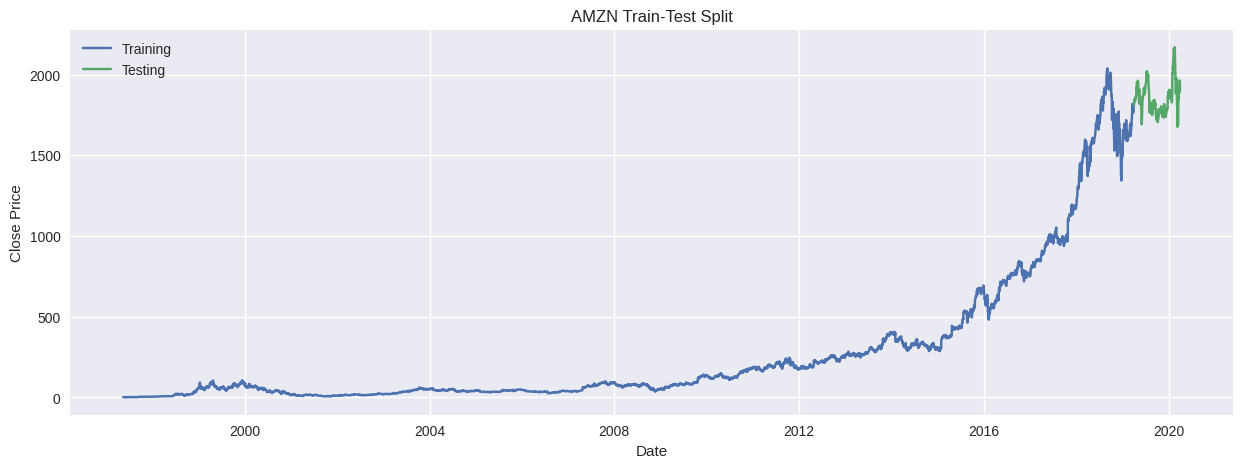

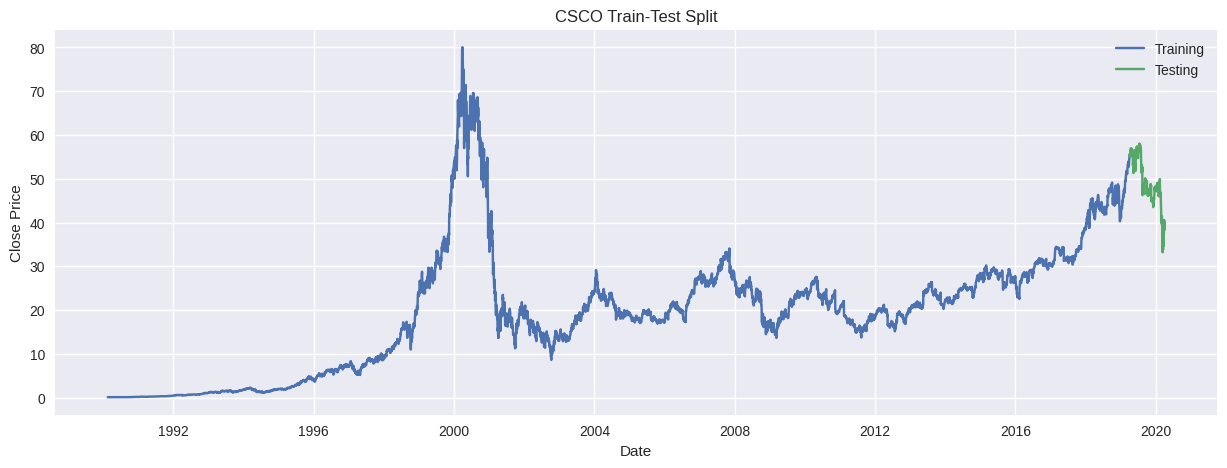

In [67]:
for name, data in processed_data.items():

    train_df = data["train_df"]
    test_df  = data["test_df"]

    plt.figure(figsize=(15,5))
    plt.plot(train_df["Date"], train_df["Close"],label="Training")
    plt.plot(test_df["Date"], test_df["Close"], label="Testing")

    plt.title(f"{name} Train-Test Split")
    plt.xlabel("Date")
    plt.ylabel("Close Price")
    plt.legend()
    plt.show()

Gambar di atas menunjukkan hasil pembagian dataset menjadi data training (biru) dan testing (hijau). Terlihat bahwa data testing berada pada periode satu tahun terakhir, sedangkan seluruh data sebelumnya digunakan sebagai data training. Pembagian secara kronologis ini memastikan model hanya memanfaatkan data historis selama proses pelatihan dan dievaluasi menggunakan data yang belum pernah dilihat sebelumnya, sehingga hasil evaluasi lebih mencerminkan kondisi prediksi di dunia nyata.

In [68]:
for name, data in processed_data.items():

    scaler = MinMaxScaler(feature_range=(0,1))

    train_scaled = scaler.fit_transform(data["train_df"][["Close"]])
    test_scaled = scaler.transform(data["test_df"][["Close"]])

    data["scaler"] = scaler
    data["train_scaled"] = train_scaled
    data["test_scaled"] = test_scaled

Sebelum digunakan sebagai input model LSTM, data harga penutupan dinormalisasi menggunakan MinMaxScaler ke dalam rentang 0 hingga 1. Proses normalisasi dilakukan dengan menyesuaikan parameter scaler hanya pada data training, kemudian parameter yang sama digunakan untuk mentransformasikan data testing. Pendekatan ini bertujuan untuk menghindari data leakage serta membantu proses pelatihan model menjadi lebih stabil karena seluruh data berada pada skala yang sama.

In [69]:
WINDOW_SIZE = 5

def create_dataset(data, window_size):
    x = []
    y = []

    for i in range(len(data) - window_size):
        x.append(data[i:i+window_size])
        y.append(data[i+window_size])

    return np.array(x), np.array(y)

Setelah dinormalisasi, data diubah menjadi bentuk supervised learning menggunakan metode sliding window dengan window size = 5 dan horizon = 1. Setiap lima data harga penutupan berturut-turut digunakan sebagai input untuk memprediksi harga pada hari berikutnya. Pendekatan ini memungkinkan model LSTM mempelajari hubungan temporal antar data historis sehingga dapat digunakan untuk melakukan prediksi harga saham.

In [70]:
def create_dataset_with_dates(data_values, dates, window_size):
    x, y, target_dates = [], [], []
    for i in range(len(data_values) - window_size):
        x.append(data_values[i:i+window_size])
        y.append(data_values[i+window_size])
        target_dates.append(dates[i+window_size])
    return np.array(x), np.array(y), np.array(target_dates)

In [71]:
for name, data in processed_data.items():
    x_train, y_train, dates_train = create_dataset_with_dates(
        data['train_scaled'],
        data['train_df']['Date'].values,
        WINDOW_SIZE
    )

    last_train_days = data['train_scaled'][-WINDOW_SIZE:]
    test_input_combined = np.vstack([last_train_days, data['test_scaled']])

    last_train_dates = data['train_df']['Date'].values[-WINDOW_SIZE:]
    test_dates_combined = np.concatenate([last_train_dates, data['test_df']['Date'].values])

    x_test, y_test, dates_test = create_dataset_with_dates(
        test_input_combined,
        test_dates_combined,
        WINDOW_SIZE
    )

    data['x_train'], data['y_train'], data['dates_train'] = x_train, y_train, dates_train
    data['x_test'], data['y_test'], data['dates_test'] = x_test, y_test, dates_test

    split_idx = int(len(x_train) * 0.9)
    data['x_tr'], data['x_val'] = x_train[:split_idx], x_train[split_idx:]
    data['y_tr'], data['y_val'] = y_train[:split_idx], y_train[split_idx:]

print('Dataset updated with dates and window gap fixed.')

Dataset updated with dates and window gap fixed.


Untuk membentuk data testing, lima data terakhir dari data training digabungkan dengan data testing sebelum proses pembentukan sliding window. Langkah ini dilakukan agar sampel pertama pada data testing tetap memiliki lima data historis sebagai input, sesuai dengan ukuran window yang digunakan. Selanjutnya, data training dibagi kembali menjadi 90% data training dan 10% data validation untuk memantau performa model selama proses pelatihan dan membantu mendeteksi terjadinya overfitting.

In [72]:
for name, data in processed_data.items():
    print(f"\n=== {name} ===")

    print("x Train:", data["x_tr"].shape)
    print("y Train:", data["y_tr"].shape)

    print()

    print("x Validation:", data["x_val"].shape)
    print("y Validation:", data["y_val"].shape)

    print()

    print("x Test:", data["x_test"].shape)
    print("y Test:", data["y_test"].shape)


=== AMZN ===
x Train: (4950, 5, 1)
y Train: (4950, 1)

x Validation: (550, 5, 1)
y Validation: (550, 1)

x Test: (253, 5, 1)
y Test: (253, 1)

=== CSCO ===
x Train: (6597, 5, 1)
y Train: (6597, 1)

x Validation: (734, 5, 1)
y Validation: (734, 1)

x Test: (253, 5, 1)
y Test: (253, 1)


In [73]:
for name, data in processed_data.items():
    print(f"\n=== {name} ===")

    print("Input (5 day):")
    print(data["x_train"][0].flatten())

    print()

    print("Target (day-6):")
    print(data["y_train"][0])


=== AMZN ===
Input (5 day):
[2.75990426e-04 1.63549843e-04 1.53328015e-04 1.17551439e-04
 1.53328015e-05]

Target (day-6):
[0.]

=== CSCO ===
Input (5 day):
[7.59631864e-05 1.08518771e-04 8.68150170e-05 9.76668475e-05
 9.22409323e-05]

Target (day-6):
[6.51112627e-05]


Output di atas menunjukkan contoh satu sampel hasil pembentukan sliding window dengan window size = 5. Lima nilai pertama merupakan data harga penutupan yang telah dinormalisasi dan digunakan sebagai input, sedangkan nilai berikutnya merupakan target atau harga penutupan pada hari ke-6 yang akan diprediksi oleh model. Nilai yang ditampilkan berada pada rentang 0–1 karena sebelumnya telah dilakukan normalisasi menggunakan MinMaxScaler. Hasil ini menunjukkan bahwa data telah berhasil diubah menjadi format supervised learning yang sesuai untuk digunakan sebagai input pada model LSTM.

## Nomor 1B. Baseline Arsitektur

Model baseline dibangun menggunakan arsitektur Sequential yang terdiri dari satu LSTM layer dengan 50 unit dan fungsi aktivasi ReLU, kemudian diikuti oleh satu Dense layer dengan 1 neuron sebagai output untuk memprediksi harga penutupan hari berikutnya. Arsitektur ini digunakan sebagai model dasar (baseline) untuk menjadi acuan sebelum dilakukan modifikasi pada tahap pengembangan model.

Model dikompilasi menggunakan optimizer Adam dan loss function Mean Squared Error (MSE). Optimizer Adam dipilih karena mampu mempercepat proses konvergensi melalui penyesuaian learning rate secara adaptif, sedangkan MSE digunakan karena merupakan fungsi loss yang umum digunakan pada permasalahan regresi dan memberikan penalti lebih besar terhadap kesalahan prediksi yang tinggi.

In [74]:
baseline_models = {}
baseline_history = {}

for name, data in processed_data.items():
    model = Sequential([
        LSTM(
            units=50,
            activation="relu",
            input_shape=(WINDOW_SIZE, 1)
        ),
        Dense(1)
    ])

    model.compile(
        optimizer="adam",
        loss="mse"
    )

    baseline_models[name] = model

    print(f"{name} Baseline Model")
    model.summary()

    print("\n")

AMZN Baseline Model


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

...

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_7 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

Model baseline dilatih menggunakan 100 epoch dengan batch size 32. Selama proses pelatihan, digunakan 90% data training sebagai data latih dan 10% data validation untuk memantau performa model pada data yang tidak digunakan dalam proses pembaruan bobot. Selain itu, parameter shuffle=False diterapkan agar urutan data tetap dipertahankan sesuai karakteristik time series, sehingga hubungan kronologis antar data tidak berubah selama proses pelatihan.

In [75]:
EPOCHS = 100
BATCH_SIZE = 32

for name, data in processed_data.items():
    print(f"=== Training Baseline Model : {name} ===")

    history = baseline_models[name].fit(

        data["x_tr"],
        data["y_tr"],

        validation_data=(
            data["x_val"],
            data["y_val"]),
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            shuffle=False,
            verbose=1
        )

    baseline_history[name] = history

=== Training Baseline Model : AMZN ===
Epoch 1/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 3.1456e-04 - val_loss: 0.0059
Epoch 2/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0020 - val_loss: 0.0033
Epoch 3/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0017 - val_loss: 6.2564e-04
Epoch 4/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 5.7010e-04 - val_loss: 0.0022
Epoch 5/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1.6767e-04 - val_loss: 0.0027
Epoch 6/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 6.4886e-05 - val_loss: 0.0033
Epoch 7/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 3.2668e-05 - val_loss: 0.0042
Epoch 8/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 2.2672e-05 - val_loss: 0.0053
Epoch 9/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.9725e-05 - val_loss: 0.0062
Epoch 10/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1.8525e-05 - val_loss: 0.0064
Epoch 11/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s

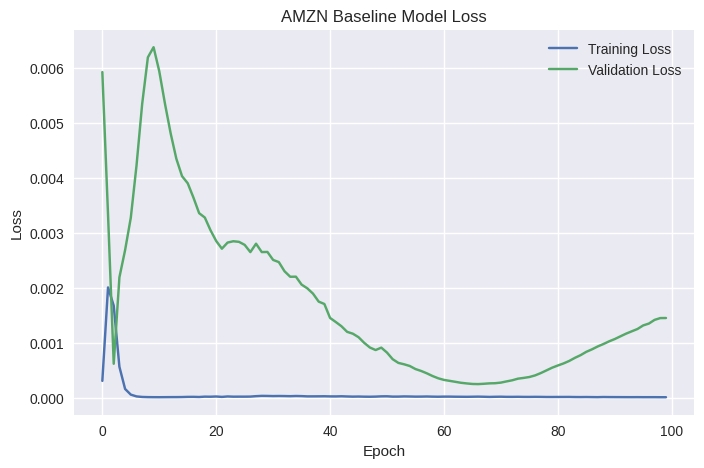

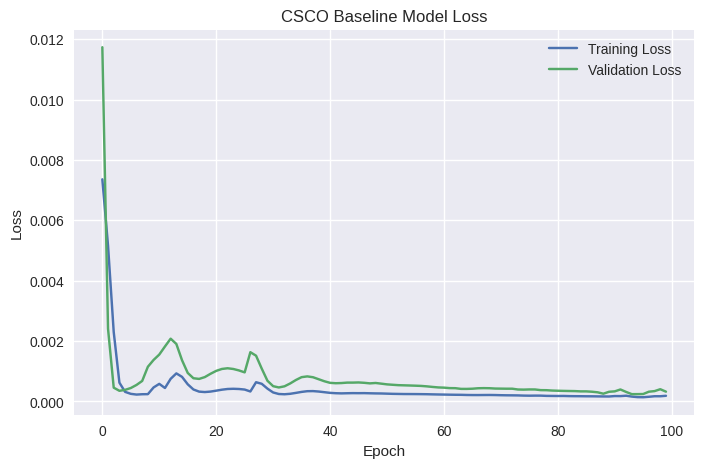

In [76]:
for name, history in baseline_history.items():
    plt.figure(figsize=(8,5))

    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")

    plt.title(f"{name} Baseline Model Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    plt.show()

Grafik menunjukkan bahwa training loss pada kedua dataset menurun seiring bertambahnya epoch, yang menandakan model berhasil mempelajari pola pada data training. Pada AMZN, validation loss sempat menurun hingga mencapai nilai minimum, kemudian kembali meningkat pada epoch akhir. Hal ini mengindikasikan adanya kecenderungan overfitting, yaitu model mulai terlalu menyesuaikan diri dengan data training. Sementara itu, pada CSCO, training loss dan validation loss cenderung menurun secara stabil dan memiliki selisih yang kecil, sehingga menunjukkan kemampuan generalisasi model yang lebih baik.

In [77]:
for name, data in processed_data.items():
    prediction = baseline_models[name].predict(data["x_test"])
    prediction = data["scaler"].inverse_transform(prediction)

    actual = data["scaler"].inverse_transform(data["y_test"].reshape(-1, 1))

    data["baseline_prediction"] = prediction
    data["actual"] = actual

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


Setelah proses pelatihan selesai, model baseline digunakan untuk memprediksi harga penutupan pada data testing. Hasil prediksi kemudian dikembalikan ke skala harga asli (inverse transform) menggunakan MinMaxScaler agar dapat dibandingkan langsung dengan nilai aktual.

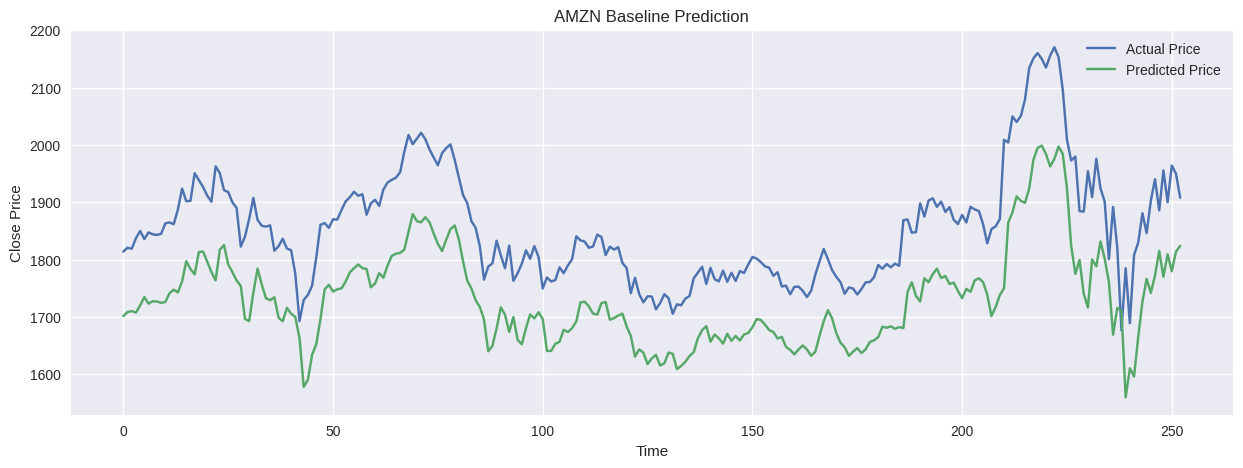

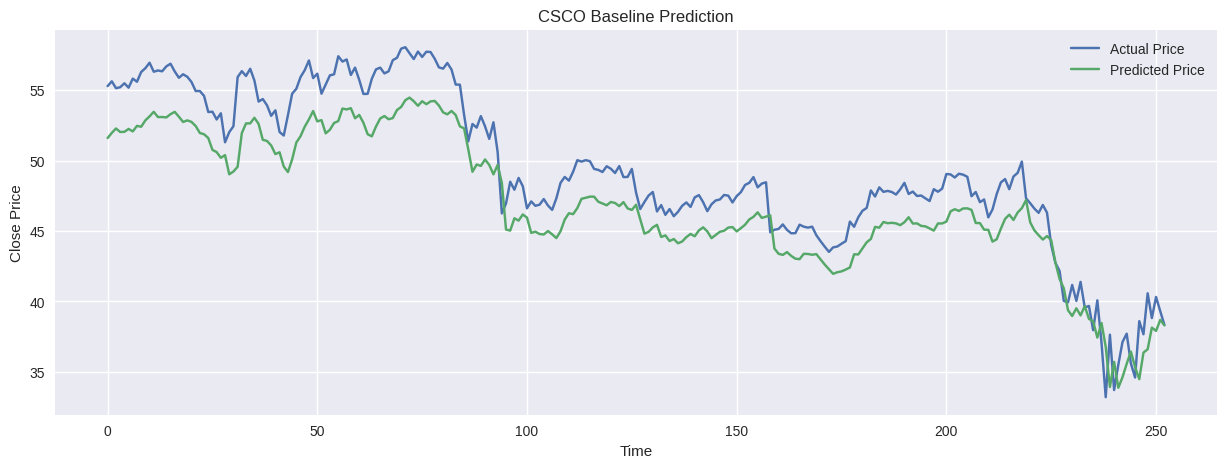

In [78]:
for name, data in processed_data.items():
    plt.figure(figsize=(15,5))

    plt.plot(data["actual"], label="Actual Price")
    plt.plot(data["baseline_prediction"], label="Predicted Price")

    plt.title(f"{name} Baseline Prediction")
    plt.xlabel("Time")
    plt.ylabel("Close Price")
    plt.legend()
    plt.show()

Berdasarkan grafik, model baseline pada kedua dataset mampu mengikuti pola pergerakan harga saham secara umum. Pada saham AMZN, prediksi berhasil menangkap tren kenaikan dan penurunan harga, namun cenderung berada di bawah nilai aktual sehingga beberapa puncak harga belum dapat diprediksi dengan baik. Sementara itu, pada saham CSCO, garis prediksi lebih dekat dengan data aktual dan mampu mengikuti pola pergerakan harga dengan lebih baik. Hal ini menunjukkan bahwa model baseline memiliki performa yang lebih baik pada dataset CSCO dibandingkan AMZN, meskipun masih terdapat selisih prediksi pada beberapa periode.

In [79]:
baseline_result = []

for name, data in processed_data.items():
    actual = data["actual"]
    prediction = data["baseline_prediction"]

    rmse = np.sqrt(mean_squared_error(actual, prediction))
    mae = mean_absolute_error(actual, prediction)
    mape = np.mean(np.abs((actual - prediction) / actual)) * 100

    baseline_result.append([name, rmse, mae, mape])

baseline_result = pd.DataFrame(baseline_result, columns=["Dataset", "RMSE", "MAE", "MAPE"])

baseline_result

,Dataset,RMSE,MAE,MAPE
0,AMZN,127.743812,123.435392,6.618837
1,CSCO,2.657170,2.472188,4.938366


## Nomor 1C. Modifikasi Arsitektur


Perubahan yang dilakukan meliputi peningkatan jumlah unit LSTM dari 50 menjadi 100, penambahan Dense layer dengan 32 neuron dan fungsi aktivasi ReLU, penggunaan regularisasi L2 pada bobot LSTM, serta penyesuaian learning rate pada optimizer Adam menjadi 0,0005.

Peningkatan jumlah unit LSTM bertujuan agar model dapat mempelajari pola temporal yang lebih kompleks. Penambahan Dense layer membantu mengekstraksi fitur yang dihasilkan oleh LSTM sebelum menghasilkan prediksi akhir. Selain itu, regularisasi L2 diterapkan untuk mengurangi risiko overfitting dengan memberikan penalti pada bobot yang terlalu besar, sedangkan penggunaan learning rate yang lebih kecil membuat proses optimisasi menjadi lebih stabil sehingga model dapat mencapai solusi yang lebih optimal.

In [81]:
improved_models  = {}
improved_history = {}

for name, data in processed_data.items():
    model = Sequential([
        LSTM(
            units=100,
            activation="relu",
            kernel_regularizer=l2(1e-4),
            recurrent_regularizer=l2(1e-4),
            input_shape=(WINDOW_SIZE, 1)
        ),

        Dense(
            units=32,
            activation="relu"
        ),

        Dense(1)

    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
        loss="mse"
    )

    improved_models[name] = model

    print(f"\n === {name} ===")

    model.summary()


 === AMZN ===


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 100)            │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         3,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,065 (172.13 KB)

 Trainable params: 44,065 (172.13 KB)

...

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_9 (LSTM)                   │ (None, 100)            │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         3,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,065 (172.13 KB)

 Trainable params: 44,065 (172.13 KB)

 Non-trainable params: 0 (0.00 B)

In [82]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=10,
    min_lr=1e-7,
    verbose=1
)

In [83]:
EPOCHS = 200
BATCH_SIZE = 32

for name, data in processed_data.items():
    print(f"=== Training Improved Model : {name} ===")

    history = improved_models[name].fit(
        data["x_tr"],
        data["y_tr"],
        validation_data=(data["x_val"],data["y_val"]),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        shuffle=False,
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )

    improved_history[name] = history

=== Training Improved Model : AMZN ===
Epoch 1/200
155/155 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0046 - val_loss: 0.0514 - learning_rate: 5.0000e-04
Epoch 2/200
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0070 - val_loss: 0.0854 - learning_rate: 5.0000e-04
Epoch 3/200
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0043 - val_loss: 0.0237 - learning_rate: 5.0000e-04
Epoch 4/200
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0021 - val_loss: 0.0029 - learning_rate: 5.0000e-04
Epoch 5/200
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 9.5819e-04 - val_loss: 0.0012 - learning_rate: 5.0000e-04
Epoch 6/200
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 4.2814e-04 - val_loss: 7.2875e-04 - learning_rate: 5.0000e-04
Epoch 7/200
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.7767e-04 - val_loss: 0.0011 - learning_rate: 5.0000e-04
Epoch 8/200
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.1119e-04 - val_loss: 0.0012 - learning_rate: 5.0000e-04
Epoch 9/200
1

Improved model dilatih menggunakan 200 epoch dengan batch size 32. Selama proses pelatihan, digunakan dua callback, yaitu EarlyStopping dan ReduceLROnPlateau, untuk meningkatkan performa model.

EarlyStopping digunakan untuk menghentikan pelatihan secara otomatis apabila validation loss tidak mengalami perbaikan selama 20 epoch berturut-turut. Selain itu, parameter restore_best_weights=True memastikan model menggunakan bobot terbaik yang diperoleh selama proses pelatihan.

Sementara itu, ReduceLROnPlateau berfungsi menurunkan learning rate sebesar 50% apabila validation loss tidak membaik selama 10 epoch, dengan batas minimum learning rate sebesar 1 × 10^-7. Penyesuaian ini membantu proses optimisasi menjadi lebih stabil dan meningkatkan peluang model mencapai performa terbaik.

Seperti pada model baseline, parameter shuffle=False digunakan agar urutan data time series tetap terjaga selama proses pelatihan. Kombinasi kedua callback tersebut diharapkan dapat mengurangi risiko overfitting sekaligus meningkatkan kemampuan generalisasi model terhadap data yang belum pernah dilihat sebelumnya.

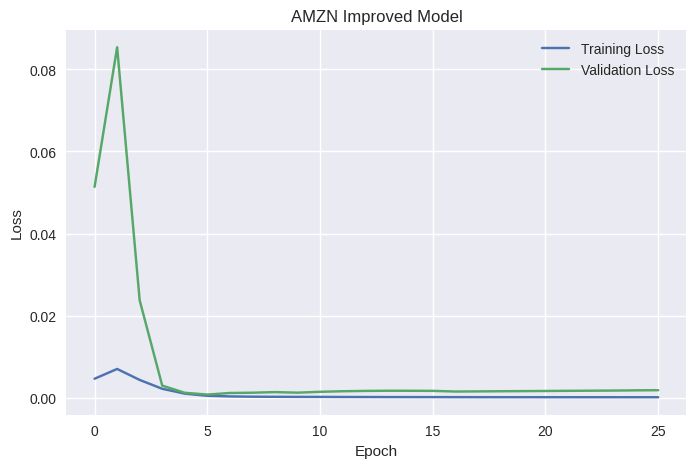

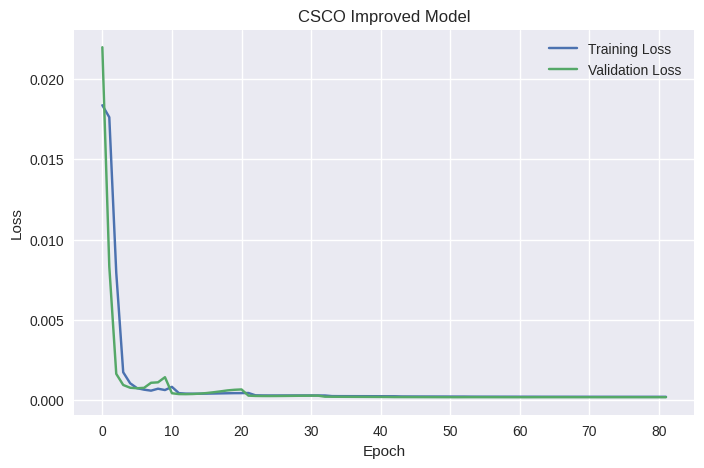

In [84]:
for name, history in improved_history.items():
    plt.figure(figsize=(8,5))
    plt.plot(
        history.history["loss"],
        label="Training Loss"
    )
    plt.plot(
        history.history["val_loss"],
        label="Validation Loss"
    )

    plt.title(f"{name} Improved Model")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

Grafik menunjukkan bahwa training loss dan validation loss pada kedua dataset mengalami penurunan yang sangat cepat pada beberapa epoch awal, kemudian cenderung stabil hingga proses pelatihan berhenti. Hal ini menunjukkan bahwa model berhasil mempelajari pola data dengan baik tanpa mengalami overfitting yang signifikan. Penggunaan EarlyStopping dan ReduceLROnPlateau juga membantu menghentikan pelatihan pada saat performa terbaik telah tercapai sehingga model tidak dilatih secara berlebihan.

In [85]:
for name, data in processed_data.items():
    prediction = improved_models[name].predict(data["x_test"])
    prediction = data["scaler"].inverse_transform(prediction)

    data["improved_prediction"] = prediction

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


Setelah proses pelatihan selesai, improved model digunakan untuk memprediksi harga penutupan pada data testing. Hasil prediksi kemudian dikembalikan ke skala harga asli (inverse transform) agar dapat dibandingkan dengan nilai aktual.

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


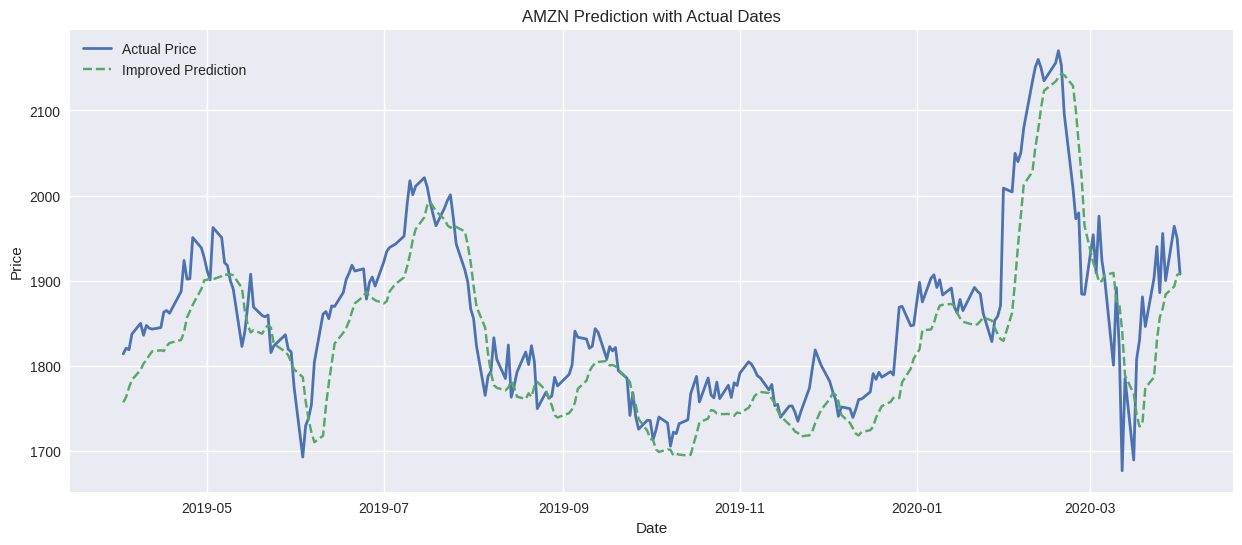

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


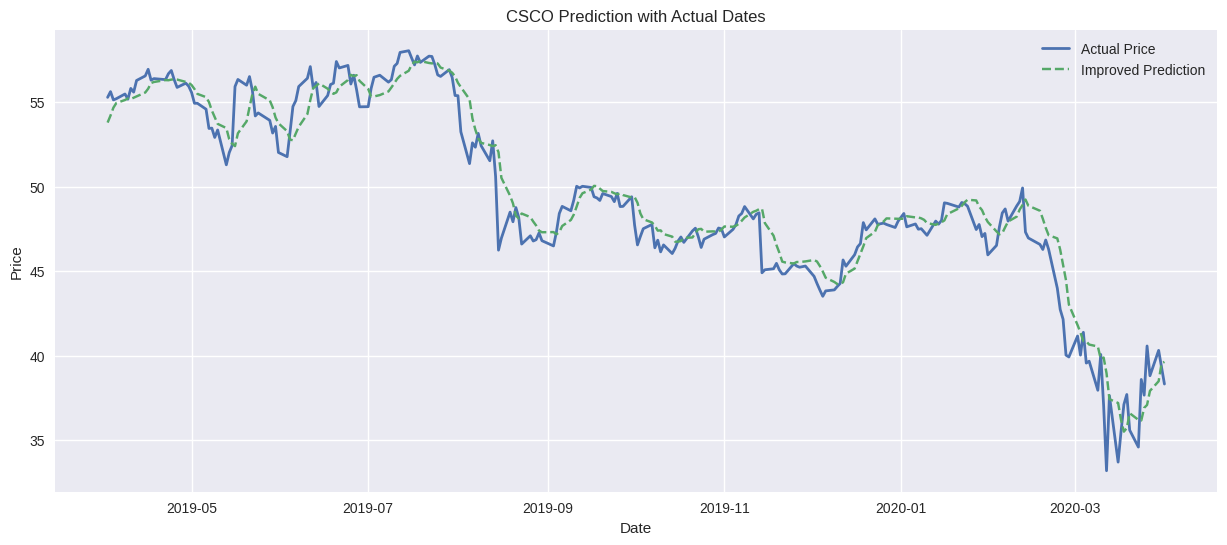

In [86]:
for name, data in processed_data.items():
    pred = improved_models[name].predict(data['x_test'])
    pred_inv = data['scaler'].inverse_transform(pred)
    actual_inv = data['scaler'].inverse_transform(data['y_test'].reshape(-1, 1))

    plt.figure(figsize=(15, 6))
    plt.plot(data['dates_test'], actual_inv, label='Actual Price', linewidth=2)
    plt.plot(data['dates_test'], pred_inv, label='Improved Prediction', linestyle='--')

    plt.title(f'{name} Prediction with Actual Dates')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend()
    plt.grid(True)
    plt.show()

Berdasarkan grafik, improved model mampu mengikuti pola pergerakan harga saham pada kedua dataset dengan baik selama periode pengujian. Pada saham AMZN, garis prediksi berhasil menangkap tren kenaikan dan penurunan harga yang terjadi, meskipun masih terdapat sedikit selisih pada beberapa titik ketika harga mengalami perubahan yang sangat tajam. Sementara itu, pada saham CSCO, garis prediksi hampir berhimpit dengan garis aktual di sebagian besar periode, menunjukkan bahwa model mampu mengikuti perubahan harga secara konsisten dengan tingkat kesalahan yang relatif kecil. Secara keseluruhan, hasil ini menunjukkan bahwa improved model memiliki kemampuan generalisasi yang baik dan mampu menghasilkan prediksi yang lebih akurat terhadap data yang belum pernah digunakan selama proses pelatihan.

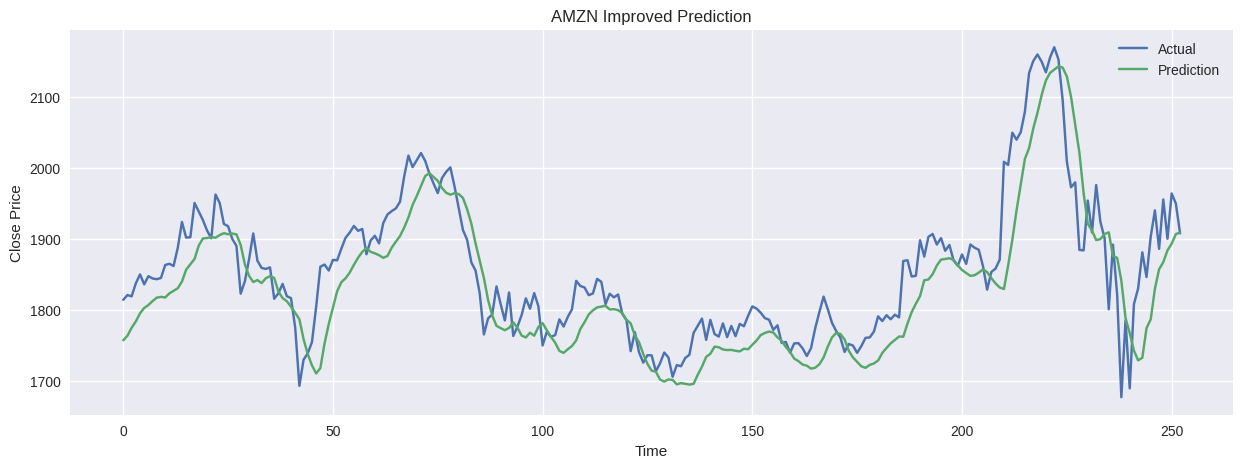

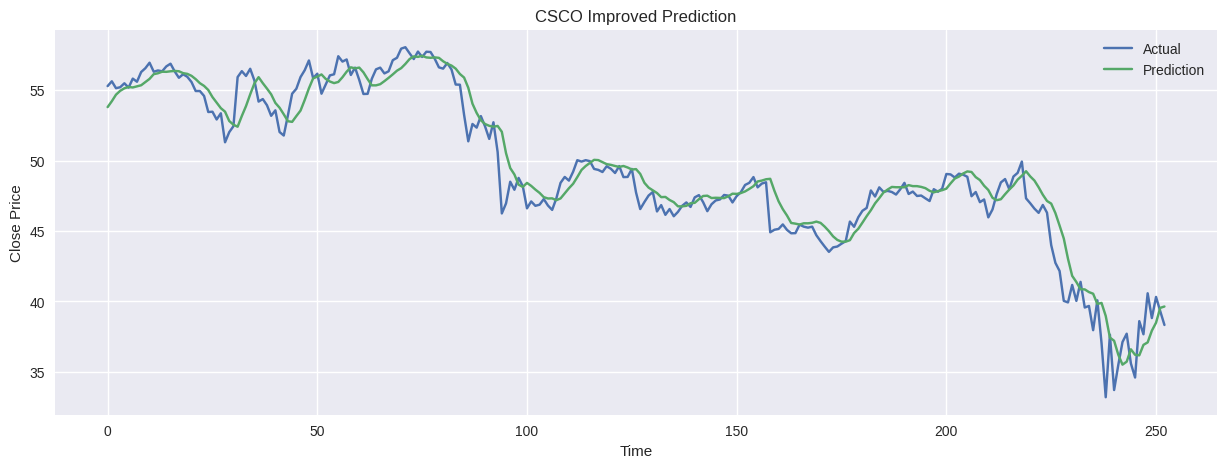

In [87]:
for name, data in processed_data.items():

    plt.figure(figsize=(15,5))

    plt.plot(data["actual"], label="Actual")
    plt.plot(data["improved_prediction"], label="Prediction")

    plt.title(f"{name} Improved Prediction")
    plt.xlabel("Time")
    plt.ylabel("Close Price")
    plt.legend()
    plt.show()

Berdasarkan grafik, improved model mampu menghasilkan prediksi yang mendekati nilai aktual pada kedua dataset. Pada saham AMZN, garis prediksi berhasil mengikuti pola kenaikan dan penurunan harga, meskipun masih terdapat sedikit keterlambatan (lag) dan selisih pada saat terjadi perubahan harga yang sangat tajam, terutama pada puncak dan lembah harga. Sementara itu, pada saham CSCO, garis prediksi hampir berhimpit dengan garis aktual di sebagian besar periode pengujian, menunjukkan bahwa model mampu menangkap pola pergerakan harga dengan baik. Secara keseluruhan, improved model menghasilkan prediksi yang lebih akurat dan mampu mengikuti tren harga saham secara konsisten pada kedua dataset.

In [88]:
improved_result = []

for name, data in processed_data.items():
    actual = data["actual"]
    prediction = data["improved_prediction"]
    rmse = np.sqrt(mean_squared_error(actual, prediction))
    mae = mean_absolute_error(actual, prediction)
    mape = np.mean(np.abs((actual-prediction)/actual))*100

    improved_result.append([name, rmse, mae, mape])

improved_result = pd.DataFrame(improved_result, columns=["Dataset", "RMSE", "MAE", "MAPE"])

improved_result

,Dataset,RMSE,MAE,MAPE
0,AMZN,52.893369,41.389551,2.211724
1,CSCO,1.358806,0.975257,2.076362


## Nomor 1D. Evaluasi Perbandingan Model

In [89]:
comparison = baseline_result.merge(
    improved_result,
    on="Dataset",
    suffixes=("_Baseline", "_Improved")
)

comparison

,Dataset,RMSE_Baseline,MAE_Baseline,MAPE_Baseline,RMSE_Improved,MAE_Improved,MAPE_Improved
0,AMZN,127.743812,123.435392,6.618837,52.893369,41.389551,2.211724
1,CSCO,2.657170,2.472188,4.938366,1.358806,0.975257,2.076362


Berdasarkan tabel hasil evaluasi, improved model menghasilkan nilai RMSE, MAE, dan MAPE yang lebih rendah dibandingkan baseline model pada kedua dataset. Pada saham AMZN, nilai RMSE menurun dari 127,74 menjadi 52,89, MAE dari 123,44 menjadi 41,39, dan MAPE dari 6,62% menjadi 2,21%. Sementara itu, pada saham CSCO, nilai RMSE turun dari 2,66 menjadi 1,36, MAE dari 2,47 menjadi 0,98, dan MAPE dari 4,94% menjadi 2,08%. Penurunan ketiga metrik tersebut menunjukkan bahwa modifikasi arsitektur berhasil meningkatkan akurasi prediksi pada kedua dataset.

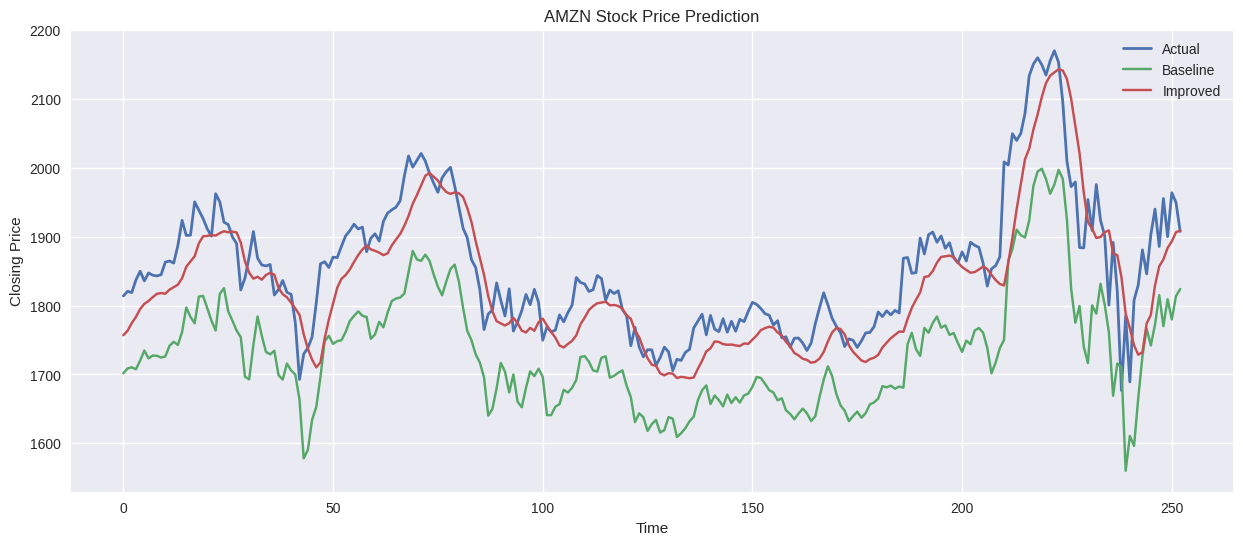

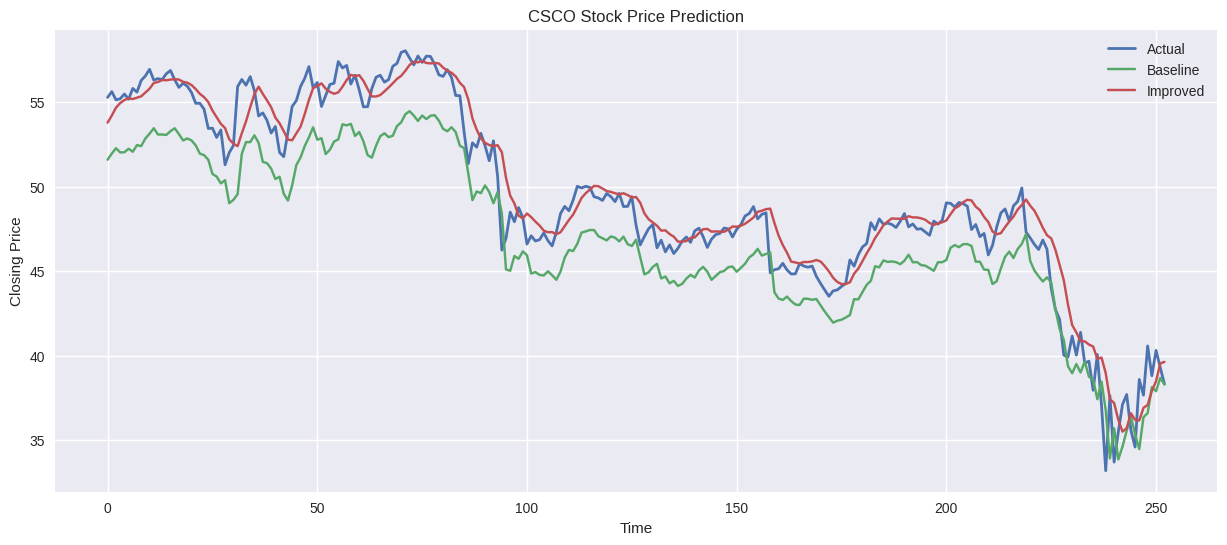

In [90]:
for name, data in processed_data.items():
    plt.figure(figsize=(15,6))
    plt.plot(data["actual"], label="Actual", linewidth=2)
    plt.plot(data["baseline_prediction"], label="Baseline")
    plt.plot(data["improved_prediction"], label="Improved")

    plt.title(f"{name} Stock Price Prediction")
    plt.xlabel("Time")
    plt.ylabel("Closing Price")
    plt.legend()
    plt.grid(True)
    plt.show()

Berdasarkan grafik, garis prediksi improved model berada lebih dekat dengan data aktual dibandingkan baseline model pada kedua dataset. Pada saham AMZN, improved model mampu mengikuti tren kenaikan dan penurunan harga dengan lebih baik, sedangkan baseline model cenderung menghasilkan prediksi yang lebih rendah dari nilai aktual. Pada saham CSCO, kedua model mampu mengikuti pola pergerakan harga, namun improved model menghasilkan prediksi yang lebih konsisten dan lebih mendekati data aktual. Hal ini menunjukkan bahwa improved model memiliki kemampuan yang lebih baik dalam mempelajari pola historis harga saham.

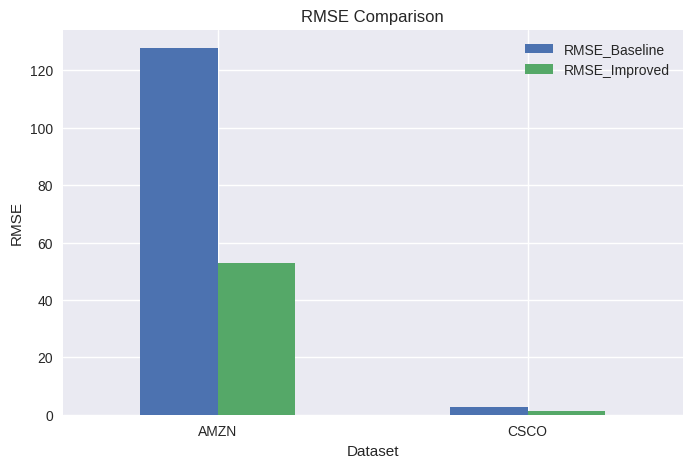

In [91]:
comparison.plot(
    x="Dataset",
    y=["RMSE_Baseline","RMSE_Improved"],
    kind="bar",
    figsize=(8,5)
)

plt.ylabel("RMSE")
plt.title("RMSE Comparison")
plt.xticks(rotation=0)
plt.show()

Grafik perbandingan RMSE menunjukkan bahwa improved model menghasilkan nilai RMSE yang lebih rendah dibandingkan baseline model pada kedua dataset. Penurunan ini terlihat sangat signifikan pada saham AMZN, sedangkan pada saham CSCO juga terjadi penurunan meskipun dalam skala yang lebih kecil. Nilai RMSE yang lebih rendah menunjukkan bahwa improved model mampu mengurangi rata-rata kesalahan prediksi sehingga menghasilkan prediksi yang lebih akurat dibandingkan model baseline.

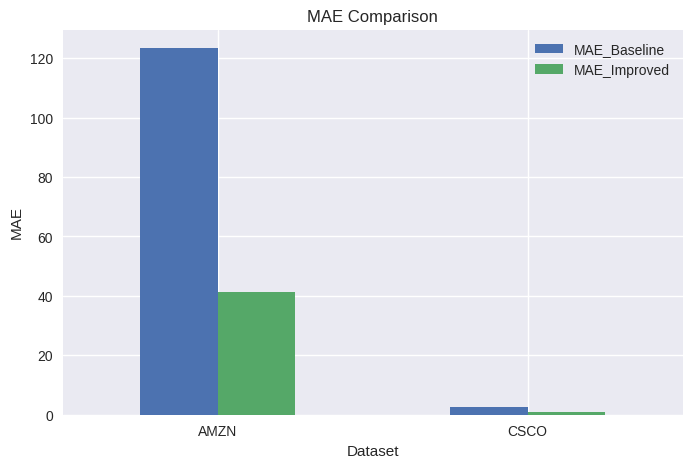

In [92]:
comparison.plot(
    x="Dataset",
    y=["MAE_Baseline","MAE_Improved"],
    kind="bar",
    figsize=(8,5)
)

plt.ylabel("MAE")
plt.title("MAE Comparison")
plt.xticks(rotation=0)
plt.show()

Grafik perbandingan MAE menunjukkan bahwa improved model menghasilkan nilai MAE yang lebih rendah dibandingkan baseline model pada kedua dataset. Penurunan nilai MAE terlihat jelas pada saham AMZN maupun CSCO, yang menunjukkan bahwa rata-rata selisih absolut antara hasil prediksi dan nilai aktual menjadi lebih kecil. Dengan demikian, improved model mampu menghasilkan prediksi yang lebih mendekati harga sebenarnya dibandingkan model baseline.

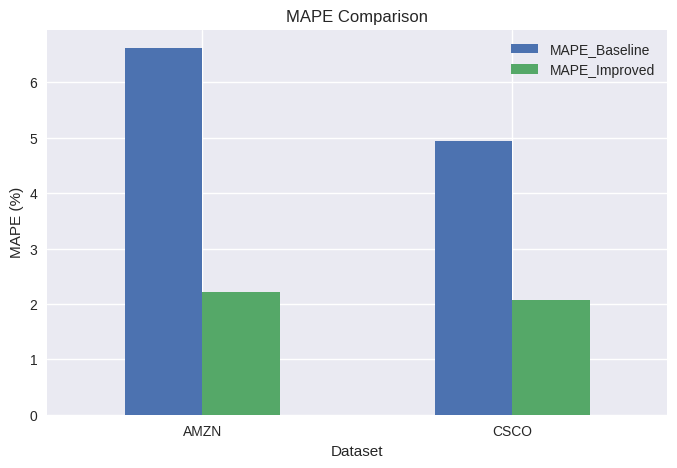

In [93]:
comparison.plot(
    x="Dataset",
    y=["MAPE_Baseline","MAPE_Improved"],
    kind="bar",
    figsize=(8,5)
)

plt.ylabel("MAPE (%)")
plt.title("MAPE Comparison")
plt.xticks(rotation=0)
plt.show()

Grafik perbandingan MAPE menunjukkan bahwa improved model juga menghasilkan nilai MAPE yang lebih rendah pada kedua dataset. Penurunan MAPE mengindikasikan bahwa persentase kesalahan prediksi terhadap harga aktual semakin kecil, sehingga akurasi model menjadi lebih baik. Hasil ini menunjukkan bahwa improved model memiliki kemampuan prediksi yang lebih baik dibandingkan baseline model, baik pada saham AMZN maupun CSCO.

In [94]:
for i in range(len(comparison)):
    dataset = comparison.loc[i, "Dataset"]

    print(dataset)

    if comparison.loc[i, "RMSE_Improved"] < comparison.loc[i, "RMSE_Baseline"]:
        print("The improved model achieved a lower RMSE.")
    else:
        print("The baseline model achieved a lower RMSE.")

    if comparison.loc[i, "MAE_Improved"] < comparison.loc[i, "MAE_Baseline"]:
        print("The improved model achieved a lower MAE.")
    else:
        print("The baseline model achieved a lower MAE.")

    if comparison.loc[i, "MAPE_Improved"] < comparison.loc[i, "MAPE_Baseline"]:
        print("The improved model achieved a lower MAPE.")
    else:
        print("The baseline model achieved a lower MAPE.")

AMZN
The improved model achieved a lower RMSE.
The improved model achieved a lower MAE.
The improved model achieved a lower MAPE.
CSCO
The improved model achieved a lower RMSE.
The improved model achieved a lower MAE.
The improved model achieved a lower MAPE.


In [95]:
def format_usd(x):
    return f"${x:,.2f}"

display_comparison = comparison.copy()

cols_to_format = ['RMSE_Baseline', 'MAE_Baseline', 'RMSE_Improved', 'MAE_Improved']
for col in cols_to_format:
    display_comparison[col] = display_comparison[col].map(format_usd)

display_comparison['MAPE_Baseline'] = display_comparison['MAPE_Baseline'].map(lambda x: f"{x:.2f}%")
display_comparison['MAPE_Improved'] = display_comparison['MAPE_Improved'].map(lambda x: f"{x:.2f}%")

print("Final Comparison (in USD):")
display(display_comparison)

Final Comparison (in USD):


,Dataset,RMSE_Baseline,MAE_Baseline,MAPE_Baseline,RMSE_Improved,MAE_Improved,MAPE_Improved
0,AMZN,$127.74,$123.44,6.62%,$52.89,$41.39,2.21%
1,CSCO,$2.66,$2.47,4.94%,$1.36,$0.98,2.08%


Hasil evaluasi menunjukkan bahwa improved model memberikan performa yang lebih baik dibandingkan baseline model pada kedua dataset. Pada dataset AMZN, nilai RMSE berhasil diturunkan dari 127,74 USD menjadi 52,89 USD, MAE dari 123,44 USD menjadi 41,39 USD, dan MAPE dari 6,62% menjadi 2,21%. Sementara itu, pada dataset CSCO, nilai RMSE menurun dari 2,66 USD menjadi 1,36 USD, MAE dari 2,47 USD menjadi 0,98 USD, dan MAPE dari 4,94% menjadi 2,08%. Penurunan ketiga metrik tersebut menunjukkan bahwa improved model mampu mengurangi kesalahan prediksi secara signifikan dan menghasilkan prediksi yang lebih mendekati nilai aktual.

## Kesimpulan

Berdasarkan hasil yang diperoleh, model Long Short-Term Memory (LSTM) mampu digunakan untuk memprediksi harga penutupan saham Amazon (AMZN) dan Cisco Systems (CSCO) dengan memanfaatkan data historis. Sebelum proses pemodelan, dilakukan beberapa tahapan persiapan data, seperti pemilihan fitur, pembagian data menjadi data pelatihan dan pengujian, normalisasi, serta pembentukan data menggunakan metode sliding window agar sesuai dengan karakteristik data time series.

Hasil evaluasi menunjukkan bahwa improved model memberikan performa yang lebih baik dibandingkan baseline model. Hal ini ditunjukkan oleh penurunan nilai RMSE, MAE, dan MAPE pada kedua dataset. Pada saham AMZN, nilai MAPE menurun dari 6,62% menjadi 2,21%, sedangkan pada saham CSCO, nilai MAPE turun dari 4,94% menjadi 2,08%. Selain itu, hasil visualisasi juga memperlihatkan bahwa improved model mampu mengikuti pola pergerakan harga saham dengan lebih baik sehingga menghasilkan prediksi yang lebih mendekati nilai aktual.

Secara keseluruhan, modifikasi yang dilakukan pada arsitektur dan hyperparameter LSTM berhasil meningkatkan akurasi prediksi dibandingkan model baseline. Oleh karena itu, improved model menjadi model yang memberikan hasil terbaik karena mampu menghasilkan prediksi yang lebih akurat dan konsisten pada kedua dataset.